In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import multivariate_normal

from PIL import Image

from jax import numpy as jnp
from matplotlib import pyplot as plt

from jwave.geometry import TimeAxis
from jwave.geometry import Medium
from jwave.geometry import Domain
from jwave.geometry import Sensors, points_on_circle


from jwave import FourierSeries

from fbpinns.analysis import FBPINN_solution
from fbpinns.analysis import load_model

import fbpinn_wave as fw
from fbpinn_wave import Wave2D

from delayandsum import applyDAS

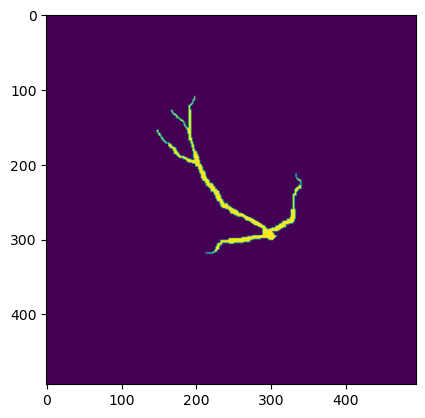

In [2]:
im = Image.open('imagenes/tejido_pequeno1.png') 

im = -(np.array(im.convert('L'))[:,8:-14]/255 - 1)

dx = 15e-3/im.shape[0]

plt.imshow(im)

N = int(0.1/dx)

In [3]:
domain = Domain((N, N), (0.1/N, 0.1/N))
medium = Medium(domain=domain, sound_speed=1490.0, attenuation=0.0, pml_size=30.0)
time_axis = TimeAxis.from_medium(medium, cfl=0.3, t_end=100e-6)
print(f"El dominio espacial en x va de {domain.spatial_axis[0].min()} m a {domain.spatial_axis[1].max()} m")
print(f"El dominio espacial en y va de {domain.spatial_axis[1].min()} m a {domain.spatial_axis[1].max()} m")

sinogram = np.load("parametros1/sinogram1.npy").T

El dominio espacial en x va de -0.04998481646180153 m a 0.04998481646180153 m
El dominio espacial en y va de -0.04998481646180153 m a 0.04998481646180153 m


In [4]:
num_sensors = 64*2
rx = 45e-3
ri = rx/domain.dx[0]
xi, yi = points_on_circle(num_sensors, ri, (int(domain.N[0]/2), int(domain.N[0]/2)))
sensors_positions = (xi, yi)
sensors = Sensors(positions=sensors_positions)

Nt = int(time_axis.Nt)
dt = time_axis.dt

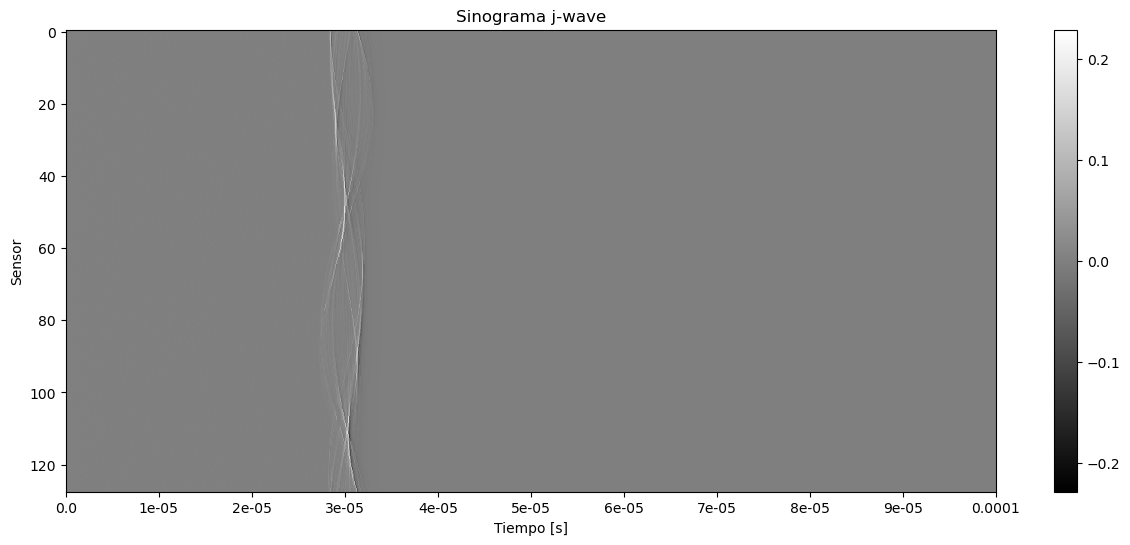

In [5]:
plt.figure(figsize=(15,6))
maxval = jnp.amax(jnp.abs(sinogram))
plt.imshow(
    sinogram,
    cmap="gray", 
    vmin=-maxval,
    vmax=maxval,
    interpolation="nearest",
    aspect="auto",
)
plt.colorbar()
num = 11
t_ticks = np.linspace(0, sinogram.shape[1], num=num)

plt.xticks(t_ticks, np.round(t_ticks*dt, decimals=5))
plt.title("Sinograma j-wave")
plt.xlabel("Tiempo [s]")
plt.ylabel("Sensor")
plt.show()

Text(0, 0.5, 'y [m]')

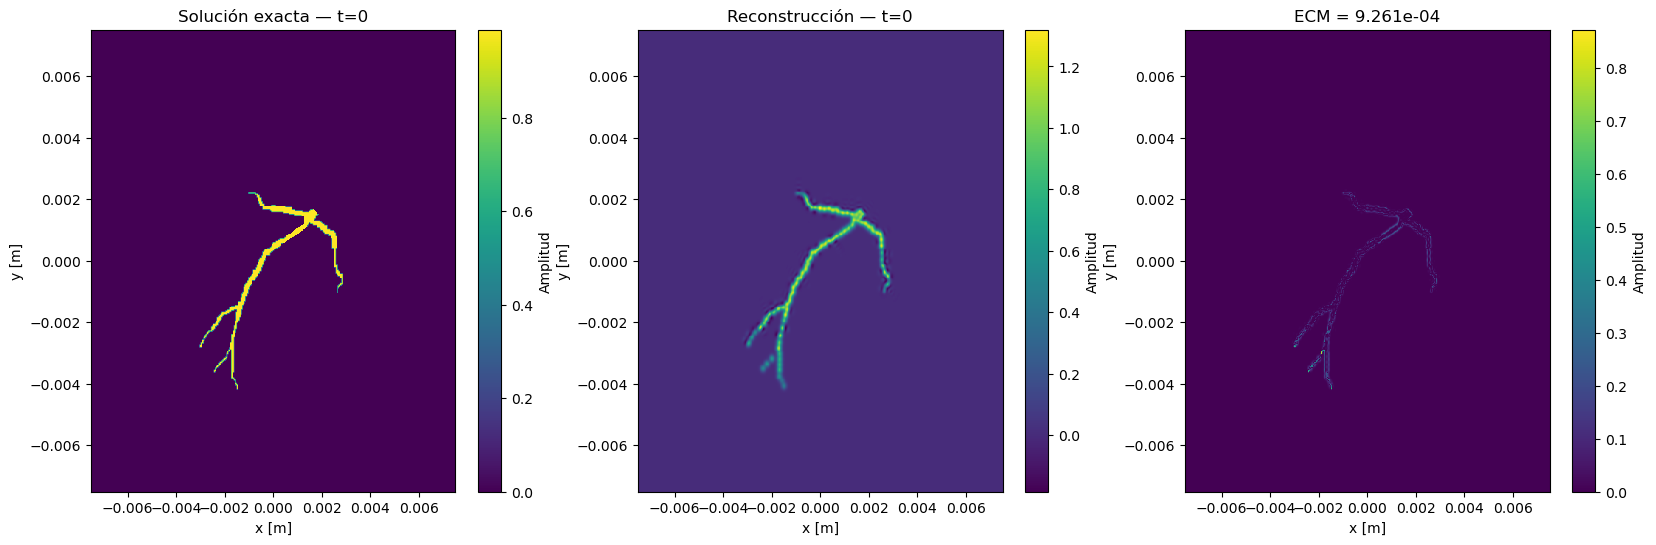

In [6]:
def gaussian_reconstruction(x, y, w, mu, cov):
    z = np.zeros_like(x)
    for i in range(0, len(w)):
        sigma = np.sqrt(cov[0][0])
        gauss = multivariate_normal(mean=mu[i], cov=cov)
        points = np.stack([x.ravel(), y.ravel()], axis=1)
        pdf = gauss.pdf(points).reshape(x.shape)
        z += w[i]*pdf*np.pi*sigma**2*2
    return z

w = np.load('parametros1/w_real1.npy')
mu = np.load('parametros1/mu_real1.npy')*7.5e-3 # Como se obtuvieron normalizando hay que desnormalizar.

sigma2 = (1.5e-3/20)**2
cov_matrix = [[sigma2,0.],[0.,sigma2]]

xx, yy = np.meshgrid(
    np.linspace(-7.5e-3, 7.5e-3, im.shape[0]),
    np.linspace(-7.5e-3, 7.5e-3, im.shape[1]),
    indexing='xy'
)

u = gaussian_reconstruction(xx,yy, w, mu, cov_matrix)

ec = (u - im)**2
ecm = np.format_float_scientific(np.mean(ec), precision=3)

fig, axes = plt.subplots(1, 3, figsize=(20,6))
ax1, ax2, ax3 = axes

im1 = ax1.pcolormesh(xx, yy, im.reshape(xx.shape))
cbar1 = plt.colorbar(im1, ax=ax1)
cbar1.set_label("Amplitud")
ax1.set_title('Solución exacta — t=0')
ax1.set_xlabel("x [m]")
ax1.set_ylabel("y [m]")

im2 = ax2.pcolormesh(xx, yy, u)
cbar2 = plt.colorbar(im2, ax=ax2)
cbar2.set_label("Amplitud")
ax2.set_title('Reconstrucción — t=0')
ax2.set_xlabel("x [m]")
ax2.set_ylabel("y [m]")

im3 = ax3.pcolormesh(xx, yy, ec)
cbar3 = plt.colorbar(im3, ax=ax3)
cbar3.set_label("Amplitud")
ax3.set_title(f'ECM = {ecm}')
ax3.set_xlabel("x [m]")
ax3.set_ylabel("y [m]")

In [7]:
Wave2D()

ri = 15e-3/domain.dx[0] # El de la red
xi, yi = points_on_circle(num_sensors, ri, (int(domain.N[0]/2), int(domain.N[0]/2)))

t = time_axis.to_array()
t = np.linspace(0, 35e-6/20, 300) # El máximo de tiempo entrenado por la red
x = (np.array(xi)- domain.N[0]/2)*domain.dx[0]/20 # Escalo acá en vez de en el radio porque si lo hago antes la precisión del círcuo es mala 
y = (np.array(yi)- domain.N[1]/2)*domain.dx[0]/20

batch_shape = (len(x), t.shape[0])

xx, tt = np.meshgrid(x, t, indexing="xy")
yy, _ = np.meshgrid(y, t, indexing="xy")

const, model = load_model(run="test", i=200000, rootdir="pulse_2d_real_extended_fine2/results/")
_, all_params, _, active, _ = model

u = FBPINN_solution(const, all_params, active, np.c_[xx.T.flatten(), yy.T.flatten(), tt.T.flatten()]).reshape(batch_shape)
u, t_new = fw.extend_sinogram(u, 15e-3/20, 1490.0, 45e-3, t[1]-t[0], 100e-6, n_resample=sinogram.shape[1], smooth=False)
sinogram_fbpinn = np.zeros_like(u)
#-----------------Sensores----------------------
ri = 45e-3/domain.dx[0]
xi, yi = points_on_circle(num_sensors, ri, (int(domain.N[0]/2), int(domain.N[0]/2)))

x = (np.array(xi)- domain.N[0]/2)*domain.dx[0]
y = (np.array(yi)- domain.N[1]/2)*domain.dx[0]
#------------------------------------------------------
for i in range(len(w)):
    sinogram_fbpinn += fw.shift_solution_sinogram(u, 45e-3, 1490, mu[i], np.c_[x,y], t_new[1] - t_new[0])*w[i] # Cambio a las nuevas posiciones de sensores
#Tarda entre 20 y 30 segundos.


[INFO] 2025-12-11 17:00:39 - Loading model from:
pulse_2d_real_extended_fine2/results/models/test/model_00200000.jax
[INFO] 2025-12-11 17:00:40 - x_batch
[INFO] 2025-12-11 17:00:40 - (38400, 3), float64, ndarray
[INFO] 2025-12-11 17:00:40 - x_take
[INFO] 2025-12-11 17:00:40 - (662400, 3), float64, ndarray


ECM = 9.166e-06


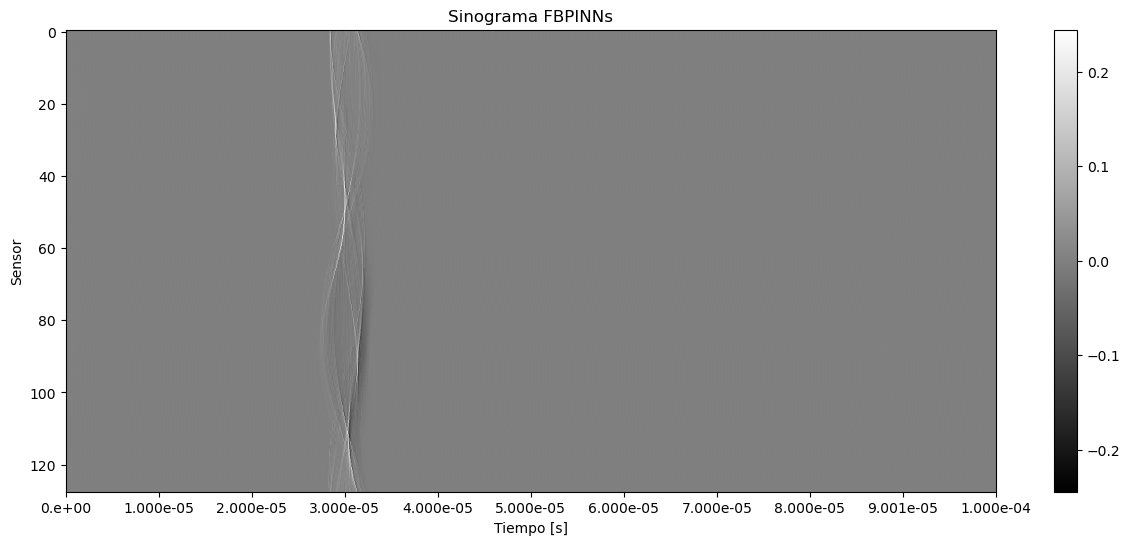

In [8]:
ec = (sinogram - sinogram_fbpinn)**2
ecm = np.format_float_scientific(np.mean(ec), precision=3)

plt.figure(figsize=(15,6))
maxval = jnp.amax(jnp.abs(sinogram_fbpinn))
plt.imshow(
    sinogram_fbpinn,
    cmap="gray",
    vmin=-maxval,
    vmax=maxval,
    interpolation="nearest",
    aspect="auto",
)
plt.colorbar()
num = 11
t_ticks = np.linspace(0, u.shape[1], num=num)
t_string = list(range(t_ticks.shape[0]))
for i in range(t_ticks.shape[0]):
    t_string[i] = np.format_float_scientific((t_ticks[i]*(t_new[1]-t_new[0])), precision=3)
plt.xticks(t_ticks, t_string)
plt.title("Sinograma FBPINNs")
plt.xlabel("Tiempo [s]")
plt.ylabel("Sensor")
print(f"ECM = {ecm}")
plt.show()

Entre reconstrucciones con DAS y la presión inicial:

FBPINNs
MSE = 5.972e-02
RMSE = 2.444e-01
PSNR = 18.47358096765628
SSIM = 0.08715331766508529
PCC = 0.6495882329864388

j-wave
MSE = 6.229e-02
RMSE = 2.496e-01
PSNR = 14.139580909831334
SSIM = 0.05734881387271013
PCC = 0.7286398170535804

Entre las reconstrucciones con DAS de FBPINNs y j-wave

MSE = 7.151e-02
RMSE = 2.674e-01
PSNR = 24.10338514591233
SSIM = 0.01800931521073377
PCC = 0.6988701875142159

Para la recnstrucción con DAS de FBPINNs y la reconstrucción con gaussianas:

MSE = 5.807e-02
RMSE = 2.41e-01
PSNR = 19.8960823715901
SSIM = 0.1096084010668626
PCC = 0.7005038226334603


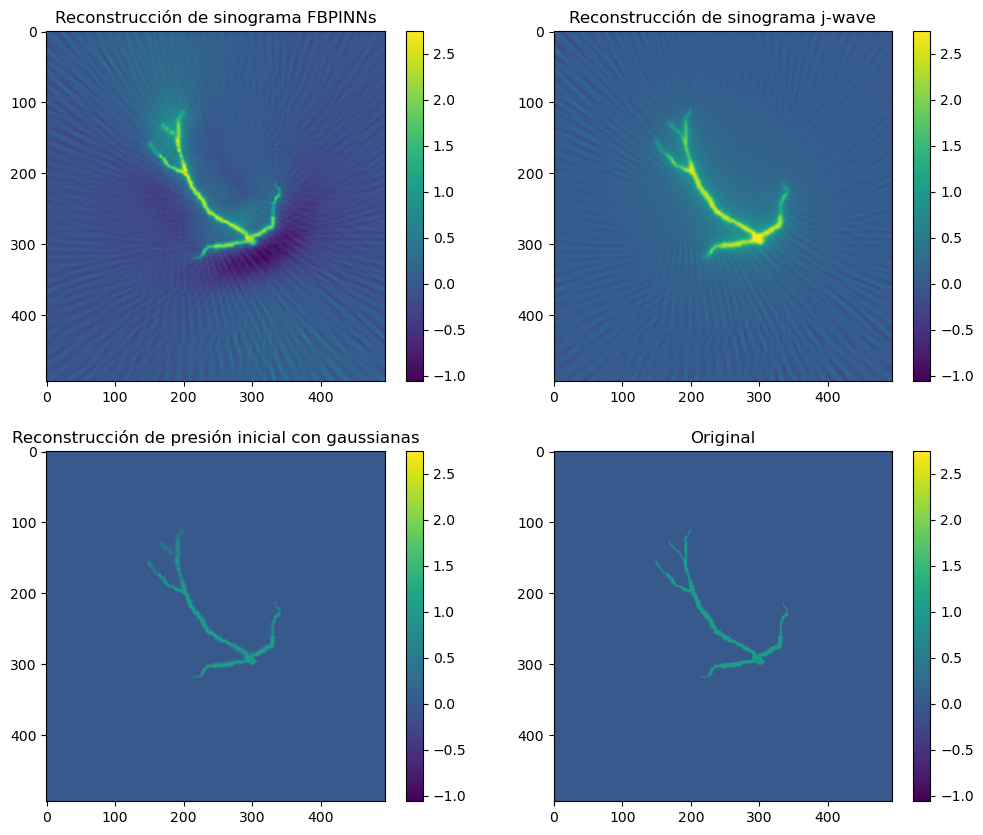

In [10]:
Pfbpinn = applyDAS(sinogram_fbpinn.shape[0], sinogram_fbpinn.shape[1], dx, im.shape[0], rx, 360, 1490, 0, 100e-6, sinogram_fbpinn)
Pjwave = applyDAS(sinogram.shape[0], sinogram.shape[1], dx, im.shape[0], rx, 360, 1490, 0, 100e-6, sinogram)

p0 = im

sigma2 = (1.5e-3/20)**2
cov_matrix = [[sigma2,0.],[0.,sigma2]]

xx, yy = np.meshgrid(np.linspace(-dx*im.shape[0]/2, dx*im.shape[0]/2, im.shape[0]), np.linspace(-dx*im.shape[0]/2, dx*im.shape[0]/2, im.shape[0]))

rec = gaussian_reconstruction(xx, yy, w, mu, cov_matrix)

plt.figure(figsize=(12,10))

vmin = np.min(Pfbpinn)
vmax = np.max(Pfbpinn)

plt.subplot(2,2,1)
plt.title('Reconstrucción de sinograma FBPINNs')
plt.imshow(
    Pfbpinn,
    aspect="auto",
    vmax=vmax,
    vmin=vmin,
)
plt.colorbar()

plt.subplot(2,2,2)
plt.title('Reconstrucción de sinograma j-wave')
plt.imshow(
    Pjwave,
    aspect="auto",
    vmax=vmax,
    vmin=vmin,
)

plt.colorbar()
plt.subplot(2,2,3)
plt.title('Reconstrucción de presión inicial con gaussianas')
plt.imshow(
    rec,
    aspect="auto",
    vmax=vmax,
    vmin=vmin,
)
plt.colorbar()

plt.subplot(2,2,4)
plt.title('Original')
plt.imshow(
    p0,
    aspect="auto",
    vmax=vmax,
    vmin=vmin,
)
plt.colorbar()

print("Entre reconstrucciones con DAS y la presión inicial:\n")
print("FBPINNs")
_ = fw.metricas_imagen(p0, Pfbpinn)
print("\nj-wave")
_ = fw.metricas_imagen(p0, Pjwave)

print("\nEntre las reconstrucciones con DAS de FBPINNs y j-wave\n")
_ = fw.metricas_imagen(Pjwave, Pfbpinn)

print("\nPara la recnstrucción con DAS de FBPINNs y la reconstrucción con gaussianas:\n")
_ = fw.metricas_imagen(rec, Pfbpinn)